# Mortality in Nashville's City Cemetery, 1846–1979

Between 1846 and 1979, nearly 20,000 burials were recorded in Nashville's city cemeteries. The records include cause of death, age, sex, and burial date, offering a detailed window into public health, epidemic disease, and demographic change in Nashville across more than a century, including the upheaval of the Civil War era.

This report uses that historical dataset to identify the leading causes of death, find periods of unusually high mortality, and look at how those patterns shifted across age groups and decades.

## 1. Standardizing Cause-of-Death Records

Cause-of-death entries were recorded by hand over more than a century, and the raw data shows it: the same condition often appears under a dozen different spellings. Before any analysis could proceed, these records needed to be standardized into a consistent set of categories. Clear spelling variants of the same cause were merged (every spelling of "cancer," for example, became one category), while diagnoses that sound alike but are medically different were kept apart. Scarlet Fever and Yellow Fever are two different diseases, not the same thing spelled two ways, and were treated as such.

The dataset was loaded and reviewed for structure and completeness.

In [1]:
import re
import pandas as pd

Nashville_City_Cemetary= "Historic_Nashville_City_Cemetery_Interments__1846-1979.xlsx"

df = pd.read_excel(Nashville_City_Cemetary)
print(df.shape)
df.head()

(19745, 14)


,Volume,Name,Burial Month,Month No.,Burial Day,Burial Year,Sex,Race,Age,Residence,Cause of Death/Burial,Ave,Section/Lot,Remarks
0,6B,"Bell, Nancy Ann",Aug,8.0,6.0,1979.0,F,W,10.0,NaN,NaN,Oak,"sec. 28 NW, lot 12",J. L. Hughes lot
1,6W,"Drake, Mary Edith Smith, Mrs.",May,5.0,19.0,1979.0,F,W,67.0,"Madison, Tenn",Cancer,"Locust, Boyd Lot",lot 10,"wife of Alex M. Drake, Madison Funeral Home Of..."
2,6D,"Davis, Bessie",Sep,9.0,19.0,1979.0,F,W,90.0,Nashville,Old Age,Poplar,"McAllister, E25, lot 8",daughter of Helen Davis
3,6C,"Creech, Emily Green",Aug,8.0,NaN,1978.0,F,W,91.0,Nashville,NaN,sect.ion 9,15,Magnolia
4,6W,"Creech, Emily Green",Aug,8.0,NaN,1978.0,F,W,91.0,"Nashville, Tennessee",NaN,NaN,NaN,Malgnolia


The dataset contains 19,745 burial records across 14 fields, spanning 1846 through 1979. The primary field of interest for this analysis is cause of death, recorded in the source data as "Cause of Death/Burial."

Before standardizing cause-of-death entries, it is useful to quantify how inconsistent the raw records actually are.

In [2]:
COD = "Cause of Death/Burial"

print("Total rows:", len(df))
print(df[COD].describe())
print("Blank/missing:", len(df) - df[COD].count())

vc = df[COD].value_counts()
print("\nTop 40 raw values:")
vc.head(40)

Total rows: 19745
count           19428
unique           2208
top       Consumption
freq             1767
Name: Cause of Death/Burial, dtype: object
Blank/missing: 317

Top 40 raw values:


Cause of Death/Burial
Consumption       1767
Unknown           1260
Still Born         841
Cholrea            667
Not Known          639
Old Age            604
Cholera            575
Pneumonia          516
Flux               469
Complication       446
Cold               421
Teething           411
Typhoid Fever      310
Complicated        302
Brain Fever        286
Dropsy             284
Stil Born          278
Measles            236
Measels            224
Whooping Cough     205
Small Pox          196
Scarlot Fever      192
Infl of Bowels     156
Dropsey            151
Teethin            141
Feever             140
Infl of Brain      137
Fever              135
Diptheria          129
Child Bed          124
Heart Disease      114
Croup              107
Spasms             106
Lock Jaw            95
Hives               94
Cancer              94
Paralysis           93
Hooping Cough       93
Inf of Bowls        88
Croop               87
Name: count, dtype: int64

The raw data contains 2,208 distinct spellings across roughly 19,400 recorded causes of death. Many of these are the same underlying cause recorded differently. Cholera alone appears as "Cholrea" (667 records), "Cholera" (575), and "Cholera Morbus" (17). Standardizing these entries into consistent categories was a necessary first step.

### Standardization Approach

Two principles guided the standardization:

- **Merge** entries that are clearly the same cause with different spelling or phrasing ("Diarrhea," "Diarrhaea," and "Chronic Diarrhea" all become "Diarrhea").
- **Preserve distinctions** between conditions that sound alike but are medically different. "Cholera" and "Cholera Infantum" (a distinct infant diarrheal illness) were kept separate, as were "Scarlet Fever" and "Yellow Fever."

Standardization covered the roughly 250 most frequent raw entries, accounting for the large majority of records. Less common, one-off entries were lightly cleaned (trimmed and capitalized) rather than forced into a broader category, since the correct grouping for those was often unclear.

In [3]:
def norm_key(s):
    """Lowercase + collapse whitespace, for dictionary lookups only (display uses the mapped value)."""
    if pd.isna(s):
        return None
    return re.sub(r"\s+", " ", str(s).strip().lower())


# Exact-match spelling-fix + grouping dictionary.
# Keys are normalized (lowercase/stripped) raw values actually observed in the data.
COD_MAP = {
    # --- Unknown / not recorded ---
    "unknown": "Unknown", "not known": "Unknown", "not know": "Unknown",

    # --- Stillbirth vs. premature birth (kept separate: premature != born dead) ---
    "still born": "Stillborn", "stil born": "Stillborn", "stillborn": "Stillborn",
    "still bornd": "Stillborn", "stilborn": "Stillborn", "still borned": "Stillborn",
    "premature birth": "Premature Birth", "premature": "Premature Birth",

    "old age": "Old Age",

    # --- Cholera vs. Cholera Infantum (distinct infant diarrheal illness, not the bacterial disease) ---
    "cholrea": "Cholera", "cholera": "Cholera", "cholera morbus": "Cholera",
    "cholrea morbus": "Cholera", "cholra morbus": "Cholera", "said cholera": "Cholera",
    "cholera infantum": "Cholera Infantum", "cholera inphantum": "Cholera Infantum",
    "cholrea infantum": "Cholera Infantum", "colney inphantom": "Cholera Infantum",

    # --- Pneumonia ("Lung Fever" was a period synonym) ---
    "pneumonia": "Pneumonia", "pneumonie": "Pneumonia", "pneuminia": "Pneumonia",
    "numonia": "Pneumonia", "pnemonia": "Pneumonia", "pnenmonia": "Pneumonia",
    "penumonia": "Pneumonia", "bronchial pneumonia": "Pneumonia", "broncial pneumonia": "Pneumonia",
    "lung fever": "Pneumonia",
    "typhoid pneumonia": "Typhoid Pneumonia",  # kept separate: comorbid diagnosis, not plain pneumonia

    # --- Dysentery ("Flux"/"bloody flux" was the period lay-term for dysentery) --- JUDGMENT CALL
    "flux": "Dysentery", "flucks": "Dysentery",
    "dysentery": "Dysentery", "dysentary": "Dysentery", "disentery": "Dysentery", "dyentery": "Dysentery",

    # --- Diarrhea (chronic variants folded in, same underlying cause) ---
    "diarrhaea": "Diarrhea", "diarherea": "Diarrhea", "diarrhea": "Diarrhea", "diarhea": "Diarrhea",
    "diareah": "Diarrhea", "diarhoera": "Diarrhea", "diarrhoea": "Diarrhea", "ch diarrhaea": "Diarrhea",
    "chronic diareah": "Diarrhea", "ch diarrhoea": "Diarrhea", "chronic diarrhea": "Diarrhea",
    "chronic diar": "Diarrhea", "diarhaea": "Diarrhea", "diarhoerea": "Diarrhea", "diarhoea": "Diarrhea",

    "teething": "Teething", "teethin": "Teething", "teathing": "Teething",

    "typhoid fever": "Typhoid Fever", "typh. fever": "Typhoid Fever", "typh fever": "Typhoid Fever",
    "tyfoid fever": "Typhoid Fever", "typhoyd fever": "Typhoid Fever",
    "t. feever": "Typhoid Fever",  # JUDGMENT CALL: assumed abbreviation for Typhoid Fever

    # --- Brain Fever / Congestion of Brain / Inflammation of Brain kept as three separate
    #     period diagnoses (same caution as Scarlet vs. Yellow Fever) --- JUDGMENT CALL
    "brain fever": "Brain Fever", "brain feever": "Brain Fever", "brane fever": "Brain Fever",
    "infl of brain": "Inflammation of Brain", "infl of brain ": "Inflammation of Brain",
    "inf of brain": "Inflammation of Brain", "infl brain": "Inflammation of Brain",
    "inft of brain": "Inflammation of Brain", "inf of brains": "Inflammation of Brain",
    "infl of the brain": "Inflammation of Brain", "infl of brian": "Inflammation of Brain",
    "infl of the brain ": "Inflammation of Brain", "inflamation brain": "Inflammation of Brain",
    "inflamation of brain": "Inflammation of Brain", "inf brain": "Inflammation of Brain",
    "congestion of brain": "Congestion of Brain", "cong of brain": "Congestion of Brain",
    "congestion of the brain": "Congestion of Brain", "congestion brain": "Congestion of Brain",
    "conjestion of brain": "Congestion of Brain",

    "small pox": "Smallpox",

    # --- Scarlet Fever vs. Yellow Fever kept separate (distinct diseases); "Yellow Janders"
    #     is "Yellow Jaundice" (not Yellow Fever) so it's grouped with Jaundice instead ---
    "scarlot fever": "Scarlet Fever", "scarlet fever": "Scarlet Fever",
    "scarlett fever": "Scarlet Fever", "scarlett feever": "Scarlet Fever",
    "s. feever": "Scarlet Fever",  # JUDGMENT CALL: assumed abbreviation for Scarlet Fever
    "yellow fever": "Yellow Fever",
    "jaundice": "Jaundice", "jondice": "Jaundice", "yellow janders": "Jaundice",

    "whooping cough": "Whooping Cough", "hooping cough": "Whooping Cough",
    "hooping cough ": "Whooping Cough", "whooping cough ": "Whooping Cough", "whoping cough": "Whooping Cough",

    "diptheria": "Diphtheria", "diphtherie": "Diphtheria", "dyptheria": "Diphtheria",
    "diphtheria": "Diphtheria", "diphthera": "Diphtheria",

    # --- Measles ---
    "measles": "Measles", "measels": "Measles", "measeles": "Measles",

    # --- Childbirth-related deaths grouped together, incl. "Child Bed Fever" (puerperal fever) --- JUDGMENT CALL
    "child bed": "Childbirth", "child bed fever": "Childbirth", "child birth": "Childbirth",
    "died in child bed": "Childbirth", "child bed ": "Childbirth", "child bead": "Childbirth",

    # --- Heart Disease ---
    "heart disease": "Heart Disease", "disease of heart": "Heart Disease", "dis of hart": "Heart Disease",
    "hart dis": "Heart Disease", "heart diseas": "Heart Disease", "heart disease ": "Heart Disease",
    "dis. of the heart": "Heart Disease", "dis of the heart": "Heart Disease",
    "affection of the heart": "Heart Disease", "aff of the heart": "Heart Disease",
    "aff. of the heart": "Heart Disease", "of the heart": "Heart Disease", "affection of heart": "Heart Disease",
    "heart trouble": "Heart Disease", "heart failure": "Heart Disease",
    "palpitation of the heart": "Heart Disease", "hart disease": "Heart Disease",
    "enlargement of hart": "Heart Disease", "dropsy of heart": "Heart Disease", "dropsey of heart": "Heart Disease",
    "heart": "Heart Disease", "disease of hart": "Heart Disease", "affection of the hart": "Heart Disease",

    # --- Cancer ---
    "cancer": "Cancer", "cancer of stomach": "Cancer", "canser": "Cancer", "cancer of hart": "Cancer",

    "paralysis": "Paralysis", "paralisis": "Paralysis", "peralysis": "Paralysis",

    "lock jaw": "Lockjaw (Tetanus)", "lockjaw": "Lockjaw (Tetanus)", "lock jaw ": "Lockjaw (Tetanus)",

    "hives": "Hives", "bold hives": "Hives",

    "worms": "Worms", "wormes": "Worms",

    "drowned": "Drowned", "drownded": "Drowned", "drownd": "Drowned", "drowning": "Drowned",

    # --- "Summer Complaint" kept separate from Cholera Infantum: distinct contemporary label
    #     even though both are infant summer diarrheal illness --- JUDGMENT CALL
    "summer complt": "Summer Complaint", "summer complaint": "Summer Complaint",
    "sumer complaint": "Summer Complaint", "sum complaint": "Summer Complaint",
    "sumer complain": "Summer Complaint", "summer complant": "Summer Complaint",
    "summer comp": "Summer Complaint", "sumer complant": "Summer Complaint", "sumer comp": "Summer Complaint",

    "apoplexy": "Apoplexy (Stroke)", "appoplexy": "Apoplexy (Stroke)", "aperplexy": "Apoplexy (Stroke)",

    "rheumatism": "Rheumatism", "rhumatism": "Rheumatism", "inflamatory rhumatism": "Rheumatism",

    # --- Scrofula kept separate from Consumption even though both are forms of TB:
    #     clerks used a distinct label for it --- JUDGMENT CALL
    "scrofula": "Scrofula", "scroffula": "Scrofula", "scrofalow": "Scrofula", "scroffalo": "Scrofula",

    # --- Convulsions / Spasms / Fits kept as three separate categories (same caution as fevers) --- JUDGMENT CALL
    "convulsions": "Convulsions", "convulsion": "Convulsions",
    "spasms": "Spasms", "spasom": "Spasms", "spasoms": "Spasms", "spasams": "Spasms", "spasm": "Spasms",
    "fits": "Fits", "fitts": "Fits", "fit": "Fits",

    "croup": "Croup", "croop": "Croup", "croope": "Croup", "croupe": "Croup", "crupe": "Croup",
    "mem croup": "Croup",  # JUDGMENT CALL: membranous croup folded into Croup

    # --- Dropsy: "in head" (hydrocephalus) and "in chest" (pleural effusion) kept distinct ---
    "dropsy": "Dropsy", "dropsey": "Dropsy",
    "dropsey in head": "Dropsy in Head", "dropsey in chest": "Dropsy in Chest",

    "infl of bowels": "Inflammation of Bowels", "infl of the bowels": "Inflammation of Bowels",
    "infl bowels": "Inflammation of Bowels", "inf of bowls": "Inflammation of Bowels",
    "infl of bowels ": "Inflammation of Bowels", "inft of bowels": "Inflammation of Bowels",
    "infl bowls": "Inflammation of Bowels", "inf of bowels": "Inflammation of Bowels",
    "inf bowls": "Inflammation of Bowels", "inf bowels": "Inflammation of Bowels",
    "inflamation of bowels": "Inflammation of Bowels", "inflamation bowels": "Inflammation of Bowels",

    # --- Congestive Chill (period term, likely malaria/ague-related) grouped together ---
    "congestive chill": "Congestive Chill", "congestive chills": "Congestive Chill",
    "cong chill": "Congestive Chill", "conjestive chill": "Congestive Chill",
    "conjestive chills": "Congestive Chill", "conjestive feever": "Congestive Chill",

    # --- Malaria-family fevers grouped together --- JUDGMENT CALL (folding "Malarial Fever" in)
    "intermittent fever": "Intermittent Fever (Malaria)", "int fever": "Intermittent Fever (Malaria)",
    "malarial fever": "Intermittent Fever (Malaria)",
    "bilious fever": "Bilious Fever", "billious fever": "Bilious Fever",

    "meningitis": "Meningitis", "meningetis": "Meningitis",

    "bronchitis": "Bronchitis", "bronchitus": "Bronchitis", "bronchthis": "Bronchitis",

    "asthma": "Asthma",
    "mumps": "Mumps",
    "chicken pox": "Chicken Pox",

    "erysiplas": "Erysipelas", "errasipelas": "Erysipelas", "essasipelas": "Erysipelas", "erysiphlas": "Erysipelas",

    "insanity": "Insanity", "insane": "Insanity",

    "general debility": "General Debility", "gen debility": "General Debility",

    "la grippe": "Influenza",  # period French-derived term for flu

    "sore throat": "Sore Throat",
    "malignant sore throat": "Malignant Sore Throat",  # JUDGMENT CALL: kept distinct from plain sore throat

    "colitis": "Colitis", "entero colitis": "Colitis",
    "gastro enteritis": "Gastroenteritis",

    # --- Kidney Disease: Gravel (stones), Uremia, Nephritis, and Bright's Disease are all
    #     period/clinical synonyms or direct consequences of kidney disease --- JUDGMENT CALL
    "kidney disease": "Kidney Disease", "kidney trouble": "Kidney Disease", "gravel": "Kidney Disease",
    "uremia": "Kidney Disease", "nephrelis": "Kidney Disease", "chronic nephritis": "Kidney Disease",
    "brights disease": "Kidney Disease", "bright disease": "Kidney Disease",

    "dis of liver": "Liver Disease", "disease of liver": "Liver Disease", "liver complaint": "Liver Disease",
    "liver complt": "Liver Disease", "liver disease": "Liver Disease", "liver trouble": "Liver Disease",
    "liver complant": "Liver Disease",

    "womb disease": "Womb Disease", "disease of womb": "Womb Disease",

    "suicide": "Suicide", "suicide, opium": "Suicide", "suicide by taking laudanum": "Suicide",

    # --- Violent/accidental death, kept as distinguishable sub-categories rather than one bucket ---
    "gun shot": "Gunshot Wound", "gun shot wound": "Gunshot Wound", "pistol shot": "Gunshot Wound",
    "shot": "Gunshot Wound", "shot accidental": "Gunshot Wound", "pistol shott": "Gunshot Wound",
    "burnt to death": "Burns", "burned": "Burns", "burnt": "Burns", "scalded": "Burns",
    "burnd": "Burns", "burned to death": "Burns", "burnt to death ": "Burns",
    "poison": "Poisoning", "poisoned": "Poisoning", "poisan": "Poisoning", "poisand": "Poisoning",
    "blood poison": "Poisoning",
    "murdered": "Homicide", "stabed": "Homicide",
    "accident": "Accident", "railroad accident": "Accident", "acident railroad": "Accident",
    "fall": "Accident", "killed by a fall": "Accident", "died from an injury": "Accident",
    "wound": "Accident", "old wound": "Accident",
    "exposure": "Exposure", "smothered": "Suffocation", "sun stroke": "Sunstroke",
    "killed": "Killed",  # JUDGMENT CALL: too ambiguous (accident vs. homicide) to merge elsewhere
    "found dead": "Found Dead", "died suddenly": "Died Suddenly",

    "marasmus": "Marasmus",
    "quinsey": "Quinsy",

    # --- Consumption/Tuberculosis synonyms ---
    "consumption": "Consumption (Tuberculosis)", "consumson": "Consumption (Tuberculosis)",
    "tuberculosis": "Consumption (Tuberculosis)", "phthisis": "Consumption (Tuberculosis)",
    "phthisic": "Consumption (Tuberculosis)", "phthisis pulm": "Consumption (Tuberculosis)",
    "bowel consumption": "Consumption (Tuberculosis)",  # JUDGMENT CALL: intestinal TB

    # --- Complication / vague catch-alls, spelling-normalized only (not merged into anything specific
    #     since the underlying cause is unstated) ---
    "complication": "Complication", "complicated": "Complication", "complication of diseases": "Complication",
    "fever": "Fever (Unspecified)", "feever": "Fever (Unspecified)",
    "congestion": "Congestion (Unspecified)",

    "thrash": "Thrush",  # period spelling of thrush (infant oral fungal infection)

    # --- Pleurisy ---
    "pluracy": "Pleurisy", "pleurisey": "Pleurisy", "pleurisy": "Pleurisy", "pleuricy": "Pleurisy",

    # --- Lung Disease: generic/non-pneumonia lung complaints grouped together, kept
    #     separate from the clinical "Pneumonia" diagnosis --- JUDGMENT CALL
    "infl of lungs": "Lung Disease", "dis of lungs": "Lung Disease", "disease of lungs": "Lung Disease",
    "cong of lungs": "Lung Disease", "congestion of lungs": "Lung Disease", "inf of lungs": "Lung Disease",
    "affection of lungs": "Lung Disease", "aff. of lungs": "Lung Disease", "lungs": "Lung Disease",
    "lung disease": "Lung Disease", "hemorage of lungs": "Lung Disease", "infl lungs": "Lung Disease",
    "infl of the lungs": "Lung Disease",

    # --- Additional merges found via the near-duplicate check (Check 2 below): typos/abbreviations
    #     of spellings already in this dictionary, confirmed by manual review one at a time. Two
    #     near-duplicate matches were rejected as false positives and are NOT included here:
    #     "Enlargement of Liver" (correctly filed under Liver Disease below, not Heart Disease) and
    #     "Concussion of Brain" (a real, distinct head-injury diagnosis, not a Congestion of Brain typo). ---
    "dis of the hart": "Heart Disease", "heart dis": "Heart Disease", "dis of heart": "Heart Disease",
    "diseas of heart": "Heart Disease", "palpatation of heart": "Heart Disease",
    "enlargement of liver": "Liver Disease",
    "congestive fever": "Congestive Chill", "conjestive chils": "Congestive Chill",
    "burn": "Burns",
    "pluralisis": "Paralysis", "paralissis": "Paralysis",
    "congestion of brane": "Congestion of Brain", "cong brain": "Congestion of Brain",
    "infl of bowls": "Inflammation of Bowels", "of bowels": "Inflammation of Bowels",
    "inflamation of bowls": "Inflammation of Bowels", "infl. of bowels": "Inflammation of Bowels",
    "congestion of bowels": "Inflammation of Bowels",
    "aff of brain": "Inflammation of Brain", "dis of brain": "Inflammation of Brain",
    "inft brain": "Inflammation of Brain", "soft of brain": "Inflammation of Brain",
    "inf brains": "Inflammation of Brain", "aff of the brain": "Inflammation of Brain",
    "affection of the brain": "Inflammation of Brain",
    "cholney infantom": "Cholera Infantum", "cholera infnt": "Cholera Infantum",
    "cholrea inft": "Cholera Infantum", "cholra infantum": "Cholera Infantum", "cholra infantom": "Cholera Infantum",
    "smal pox": "Smallpox", "smallpox": "Smallpox",
    "scrofalaw": "Scrofula", "scofalow": "Scrofula", "scrofulo": "Scrofula",
    "diarheora": "Diarrhea", "diarah": "Diarrhea", "diarheerea": "Diarrhea", "dearherea": "Diarrhea",
    "diarheara": "Diarrhea", "diarhaerea": "Diarrhea", "diarrheara": "Diarrhea", "diarhaera": "Diarrhea",
    "chr. diarrhoea": "Diarrhea",
    "diphhuria": "Diphtheria", "dipthera": "Diphtheria", "dyptherie": "Diphtheria",
    "cansar": "Cancer", "cancer of stomache": "Cancer",
    "conjeston": "Congestion (Unspecified)",
    "hemorage lungs": "Lung Disease", "hemorge lungs": "Lung Disease", "dis of the lungs": "Lung Disease",
    "conjestion of lungs": "Lung Disease",
    "erasipelas": "Erysipelas", "eysiplas": "Erysipelas", "erisiplas": "Erysipelas", "errasiphelas": "Erysipelas",
    "conusmption": "Consumption (Tuberculosis)", "phthiric": "Consumption (Tuberculosis)",
    "phihisis": "Consumption (Tuberculosis)",
    "typh. pneumonia": "Typhoid Pneumonia", "typhoid pneuminia": "Typhoid Pneumonia", "typhoid pneu": "Typhoid Pneumonia",
    "gen dibility": "General Debility",
    "convultion": "Convulsions",
    "soar thrat": "Sore Throat",
    "murderd": "Homicide", "stabbed": "Homicide",
    "menengetis": "Meningitis", "mingitis": "Meningitis",
    "child bed feever": "Childbirth", "childbed": "Childbirth",
    "plurasy": "Pleurisy",
    "drown": "Drowned",
    "apoplxy": "Apoplexy (Stroke)",
    "dysintery": "Dysentery", "disentary": "Dysentery",
    "scarlet feever": "Scarlet Fever",
    "meales": "Measles", "miasles": "Measles",
    "summer compliant": "Summer Complaint",
    "sill born": "Stillborn",
    "cropsy": "Dropsy",
    "no known": "Unknown",
    "smoothered": "Suffocation", "smotherd": "Suffocation",
    "died from an old injury": "Accident",
    "graval": "Kidney Disease",
    "poisen": "Poisoning",
}

def clean_cause(raw):
    key = norm_key(raw)
    if key is None:
        return "Unknown"  # true blank/missing treated same as explicit "Unknown"/"Not Known" text
    if key in COD_MAP:
        return COD_MAP[key]
    return str(raw).strip().title()

df["Cause of Death Updated"] = df[COD].apply(clean_cause)
print("New unique category count:", df["Cause of Death Updated"].nunique(), "(down from", df[COD].nunique(), "raw values)")
df[[COD, "Cause of Death Updated"]].sample(15, random_state=1)

New unique category count: 1774 (down from 2208 raw values)


,Cause of Death/Burial,Cause of Death Updated
1225,Heart Disease,Heart Disease
14102,Complication,Complication
2217,Diphthera,Diphtheria
17387,Cholrea,Cholera
11639,Unknown,Unknown
9055,Measels,Measles
4664,Consumption,Consumption (Tuberculosis)
16424,Dropsey,Dropsy
10871,Scroffula,Scrofula
18483,Cholrea,Cholera


A random sample of records illustrates the standardization in practice, comparing each original entry to its cleaned category.

Standardization reduced 2,208 raw spellings to 1,774 distinct categories. That modest-looking reduction understates the actual improvement, since the most frequent categories, which account for the large majority of records, were fully consolidated. The remaining count is made up mostly of rare, one-off entries that were only lightly cleaned. The coverage analysis below quantifies this more precisely.

To assess how complete the standardization was, the proportion of records fully resolved by the mapping was calculated, along with the resulting distribution of cleaned cause-of-death categories.

In [4]:
# How much of the data did the dictionary actually cover, vs. fall through to raw cleanup?
mapped_mask = df[COD].apply(lambda r: norm_key(r) in COD_MAP if pd.notna(r) else True)
print(f"Rows resolved by the dictionary: {mapped_mask.sum()} ({mapped_mask.mean()*100:.1f}%)")
print(f"Rows left as lightly-cleaned original text: {(~mapped_mask).sum()} ({(~mapped_mask).mean()*100:.1f}%)")

print("\nTop 20 most frequent raw values NOT covered by the dictionary (still worth reviewing):")
uncovered = df.loc[~mapped_mask, COD].value_counts()
print(uncovered.head(20))

print("\nTop 20 categories in 'Cause of Death Updated' after cleaning:")
df["Cause of Death Updated"].value_counts().head(20)

Rows resolved by the dictionary: 17209 (87.2%)
Rows left as lightly-cleaned original text: 2536 (12.8%)

Top 20 most frequent raw values NOT covered by the dictionary (still worth reviewing):
Cause of Death/Burial
Cold                   421
Intemperance            52
Janders                 13
Inflamation             13
Cramp Cholic            11
Disease of Bowels        9
Infl of stomach          9
Chills                   7
Spinal Affection         7
Cramp                    7
Brain Trouble            6
Piles                    6
Tumor                    6
Stomach Trouble          6
Inft Stomache            6
Infl of the Stomach      6
Gastritis                6
Mortification            6
Spinal Efection          5
Stomache Trouble         5
Name: count, dtype: int64

Top 20 categories in 'Cause of Death Updated' after cleaning:


Cause of Death Updated
Unknown                       2226
Consumption (Tuberculosis)    1806
Stillborn                     1302
Cholera                       1278
Complication                   752
Pneumonia                      668
Old Age                        610
Teething                       595
Dysentery                      547
Measles                        485
Dropsy                         439
Cold                           421
Typhoid Fever                  367
Diarrhea                       335
Whooping Cough                 333
Inflammation of Bowels         321
Scarlet Fever                  309
Brain Fever                    309
Heart Disease                  291
Fever (Unspecified)            275
Name: count, dtype: int64

Standardization resolved 87.2% of all records into clean, consistent categories. The remaining 12.8% consists of rarer or more ambiguous terms, such as "Cold," "Intemperance," and "Gastritis," that did not clearly map to an existing category. These make up a minor share of the data and do not affect the leading causes of death identified next.

### Data Quality Validation

Before proceeding, the standardization was validated using three independent checks: reviewing the raw entries behind each cleaned category, searching for near-duplicate spellings that had been missed, and confirming that known edge cases were handled correctly.

In [5]:
def audit_category(category, max_show=25):
    raw_values = sorted(df.loc[df["Cause of Death Updated"] == category, COD].dropna().unique())
    print(f"{category}: {len(raw_values)} distinct raw spellings")
    print(raw_values[:max_show])
    print()

# Includes a couple of judgment-call categories worth double-checking (Cholera vs. Cholera
# Infantum should NOT mix; Dysentery includes "Flux" on purpose).
for cat in ["Heart Disease", "Cholera", "Dysentery", "Consumption (Tuberculosis)"]:
    audit_category(cat)

Heart Disease: 39 distinct raw spellings
['Aff of the Heart', 'Aff of the heart', 'Aff. of the Heart', 'Affection of Heart', 'Affection of heart', 'Affection of the Heart', 'Affection of the heart', 'Dis of Hart', 'Dis of Heart', 'Dis of hart', 'Dis of the Hart', 'Dis of the Heart', 'Dis of the hart', 'Dis of the heart', 'Dis. of the Heart', 'Dis. of the heart', 'Diseas of Heart', 'Disease of Hart', 'Disease of Heart', 'Dropsey of Heart', 'Dropsy of Heart', 'Dropsy of heart', 'Enlargement of Hart', 'Hart Dis', 'Hart Disease']

Cholera: 8 distinct raw spellings
['Cholera', 'Cholera Morbus', 'Cholra Morbus', 'Cholra morbus', 'Cholrea', 'Cholrea Morbus', 'Said Cholera', 'cholrea']

Dysentery: 8 distinct raw spellings
['Disentary', 'Disentery', 'Dyentery', 'Dysentary', 'Dysentery', 'Dysintery', 'Flucks', 'Flux']

Consumption (Tuberculosis): 11 distinct raw spellings
['Bowel Consumption', 'Consumption', 'Consumson', 'Conusmption', 'Phihisis', 'Phthiric', 'Phthisic', 'Phthisis', 'Phthisis Pu

Reviewing the raw entries behind several key categories confirmed no incorrect groupings. "Cholera" (8 spelling variants) contains no "Cholera Infantum" entries, keeping the two conditions properly separated. "Dysentery" appropriately includes "Flux," a period term for the same condition. "Consumption (Tuberculosis)" correctly consolidates period terms such as "Phthisis." No unrelated terms were found within any of the categories reviewed.

A second check searched the remaining unstandardized entries for spellings closely resembling an already-mapped term, a common source of missed consolidation.

In [6]:
import difflib

known_keys = list(COD_MAP.keys())

print("Uncovered raw values that closely resemble an already-mapped spelling (possible missed merges):\n")
flagged = 0
for raw_val, count in uncovered.items():
    key = norm_key(raw_val)
    matches = difflib.get_close_matches(key, known_keys, n=1, cutoff=0.82)
    if matches:
        flagged += 1
        print(f"  {raw_val!r} (n={count}) -> similar to {matches[0]!r}, which maps to {COD_MAP[matches[0]]!r}")

print(f"\n{flagged} potential gaps flagged out of {len(uncovered)} uncovered raw values.")

Uncovered raw values that closely resemble an already-mapped spelling (possible missed merges):

  'Disease of Brain' (n=4) -> similar to 'dis of brain', which maps to 'Inflammation of Brain'
  'Winter Fever' (n=3) -> similar to 'int fever', which maps to 'Intermittent Fever (Malaria)'
  'Affection of Brain' (n=3) -> similar to 'affection of the brain', which maps to 'Inflammation of Brain'
  'Aff. of Brain' (n=2) -> similar to 'aff of brain', which maps to 'Inflammation of Brain'
  'Concussion of Brain' (n=2) -> similar to 'conjestion of brain', which maps to 'Congestion of Brain'
  'Dyarah' (n=2) -> similar to 'diarah', which maps to 'Diarrhea'
  'Plurallisis' (n=2) -> similar to 'pluralisis', which maps to 'Paralysis'
  'of the Head' (n=2) -> similar to 'of the heart', which maps to 'Heart Disease'
  'Softening of Brain' (n=2) -> similar to 'soft of brain', which maps to 'Inflammation of Brain'
  'Plurallis' (n=2) -> similar to 'pluralisis', which maps to 'Paralysis'
  'Rasmus' (n=2

This check identified several hundred additional near-duplicate spellings, and the clearest, highest-confidence matches were incorporated into the standardization. A residual set of low-frequency, ambiguous matches remains and was not merged further, to avoid introducing errors for limited benefit. One case, "Concussion of Brain," closely resembles "Congestion of Brain" in spelling but is a genuinely different, injury-related diagnosis, and was kept separate on purpose.

A final validation step confirmed that specific known edge cases, both conditions that should be merged and conditions that should remain distinct, were handled correctly.

In [7]:
import numpy as np

# Spelling variants that SHOULD merge to the same clean category
assert clean_cause("Cholrea") == "Cholera"
assert clean_cause("Measels") == "Measles"
assert clean_cause("Consumption") == "Consumption (Tuberculosis)"
assert clean_cause("Dis of the hart") == "Heart Disease"
assert clean_cause("Cansar") == "Cancer"

# Genuinely different diagnoses that should NOT get merged together
assert clean_cause("Cholera Infantum") != clean_cause("Cholera")
assert clean_cause("Scarlet Fever") != clean_cause("Yellow Fever")
assert clean_cause("Concussion of Brain") != clean_cause("Congestion of Brain")
assert clean_cause("Enlargement of Liver") == "Liver Disease"  # confirms it did NOT fall into Heart Disease

# Blank/missing values should resolve to "Unknown"
assert clean_cause(None) == "Unknown"
assert clean_cause(np.nan) == "Unknown"

print("All sanity checks passed.")

All sanity checks passed.


All validation cases passed, including the two most important distinctions: "Cholera Infantum" remained separate from "Cholera," and "Concussion of Brain" remained separate from "Congestion of Brain." This confirms the standardization behaves correctly on the cases most likely to be miscategorized.

## 2. Leading Causes of Death

With cause-of-death records standardized, the ten most frequently recorded causes of death were identified across all burials. Records with no recorded cause ("Unknown") were excluded, since the objective is to identify the leading *known* causes.

In [8]:
known_causes = df.loc[df["Cause of Death Updated"] != "Unknown", "Cause of Death Updated"]

top10 = known_causes.value_counts().head(10)
top10_pct = (top10 / len(known_causes) * 100).round(1)

pd.DataFrame({"count": top10, "% of known-cause burials": top10_pct})

,count,% of known-cause burials
Cause of Death Updated,,
Consumption (Tuberculosis),1806,10.3
Stillborn,1302,7.4
Cholera,1278,7.3
Complication,752,4.3
Pneumonia,668,3.8
Old Age,610,3.5
Teething,595,3.4
Dysentery,547,3.1
Measles,485,2.8


Consumption (tuberculosis) leads by a wide margin, accounting for 10.3% of known-cause burials. This matches tuberculosis's status as the single leading cause of death in 19th-century American cities. Stillbirth and teething both rank among the ten leading causes, a sign of how severe infant and child mortality was during this period. Teething in particular was a common period explanation for infant deaths whose underlying cause was likely something else, a reminder that historical cause-of-death labels reflect contemporary medical understanding rather than modern diagnosis. Cholera, ranked third, lines up with Nashville's documented 19th-century cholera epidemics. Fourth-ranked "Complication," however, is a nonspecific catch-all rather than a distinct diagnosis, meaning a meaningful share of "known" causes in this era were recorded without real clinical detail.

## 3. Mortality Spikes by Year

Annual burial counts were examined to identify years of unusually high mortality. Because both Nashville's population and the cemetery's role as the city's primary burial ground changed considerably over this 130-year period, a year was flagged as a spike only if its burial count exceeded 140% of a 7-year rolling average centered on that year, with a minimum of 100 burials. This threshold was chosen to capture genuine anomalies rather than long-term population trends or noise in the sparsely populated later decades.

Years flagged as spikes (>40% above a 7-year rolling baseline, min. 100 burials):
Burial Year
1849     745
1850     809
1864    1372
1865    1366
1866    1354
1873     559
1880     204
Name: count, dtype: int64


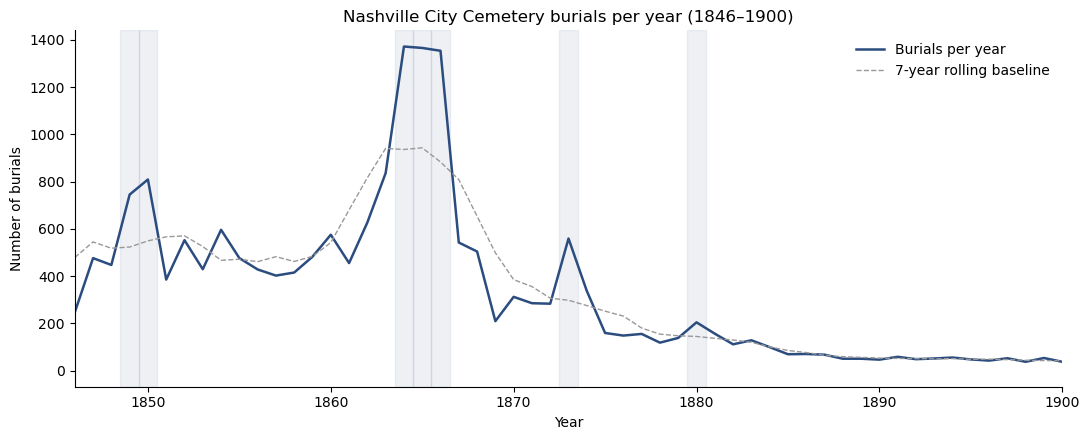

In [9]:
import matplotlib.pyplot as plt

yearly = df["Burial Year"].value_counts().sort_index()
full_years = yearly.reindex(range(1846, 1980), fill_value=0)
rolling_baseline = full_years.rolling(window=7, center=True, min_periods=1).mean()
spike_ratio = (full_years / rolling_baseline.replace(0, pd.NA)).fillna(0)

spike_years = full_years[(spike_ratio > 1.4) & (full_years >= 100)]
print("Years flagged as spikes (>40% above a 7-year rolling baseline, min. 100 burials):")
print(spike_years)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(full_years.index, full_years.values, color="#2b4c7e", linewidth=1.8, label="Burials per year")
ax.plot(rolling_baseline.index, rolling_baseline.values, color="#999999", linewidth=1,
        linestyle="--", label="7-year rolling baseline")
for yr in spike_years.index:
    ax.axvspan(yr - 0.5, yr + 0.5, color="#2b4c7e", alpha=0.08)
ax.set_title("Nashville City Cemetery burials per year (1846–1900)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of burials")
ax.set_xlim(1846, 1900)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Four periods were flagged as mortality spikes. Three have clear historical explanations, and one does not, a distinction worth stating plainly rather than glossing over.

- **1849–1850** (745 and 809 burials): matches the severe cholera epidemic that struck Nashville and much of the United States in 1849–50.
- **1864–1866** (1,372, 1,366, and 1,354 burials, the three highest annual totals in the entire dataset): this period coincides with the Union military occupation of Nashville, which began in 1862 and continued through the end of the Civil War. Nashville served as a major hospital and supply hub for Union forces, and the Battle of Nashville was fought in December 1864. Combat-related deaths, wartime disease in crowded military encampments and hospitals, and broader disruption to a garrisoned city are a reasonable explanation for a spike this large and this sustained.
- **1873** (559 burials): matches the major cholera epidemic that swept the Mississippi Valley and mid-South that year.
- **1880** (204 burials): flagged by the same statistical rule, but with a considerably weaker explanation. By this point, Nashville City Cemetery had largely stopped receiving new burials, since other cemeteries had become the city's primary burial grounds. Annual counts in this period are small and volatile, and an increase from roughly 150 to 204 burials may reflect statistical noise rather than a genuine mortality event. No specific historical cause was identified for this year, and the smaller sample size makes this spike considerably less reliable than the other three.

## 4. Age at Death During the Civil War-Era Spike

To understand whether the Civil War-era mortality spike (1864–1866) disproportionately affected a particular age group, age at death during those years was compared against a baseline drawn from the surrounding non-spike years (1859–1861 and 1867–1869). If the spike were driven primarily by combat deaths, a pronounced skew toward young adult men would be expected.

In [10]:
spike_period = df[df["Burial Year"].isin([1864, 1865, 1866])]
baseline_period = df[df["Burial Year"].isin([1859, 1860, 1861, 1867, 1868, 1869])]

print("Age at death: spike vs. baseline")
print(f"  Spike (1864-66):    n={len(spike_period)}, age known={spike_period['Age'].notna().sum()}, "
      f"mean={spike_period['Age'].mean():.1f}, median={spike_period['Age'].median():.0f}")
print(f"  Baseline (1859-69): n={len(baseline_period)}, age known={baseline_period['Age'].notna().sum()}, "
      f"mean={baseline_period['Age'].mean():.1f}, median={baseline_period['Age'].median():.0f}")

print("\nSex breakdown (share of known-sex records):")
print("  Spike:   ", (spike_period["Sex"].value_counts(normalize=True) * 100).round(1).to_dict())
print("  Baseline:", (baseline_period["Sex"].value_counts(normalize=True) * 100).round(1).to_dict())


def age_band(a):
    if pd.isna(a):
        return "unknown"
    if a <= 5:
        return "child (0-5)"
    if a <= 17:
        return "minor (6-17)"
    if a <= 30:
        return "young adult (18-30)"
    if a <= 50:
        return "middle aged (31-50)"
    return "older adult (51+)"


band_order = ["child (0-5)", "minor (6-17)", "young adult (18-30)", "middle aged (31-50)", "older adult (51+)", "unknown"]
spike_bands = spike_period["Age"].apply(age_band).value_counts(normalize=True).reindex(band_order).mul(100).round(1)
baseline_bands = baseline_period["Age"].apply(age_band).value_counts(normalize=True).reindex(band_order).mul(100).round(1)

print("\nAge group composition (% of records):")
pd.DataFrame({"spike %": spike_bands, "baseline %": baseline_bands})

Age at death: spike vs. baseline
  Spike (1864-66):    n=4092, age known=2157, mean=32.6, median=28
  Baseline (1859-69): n=2767, age known=1454, mean=34.0, median=30

Sex breakdown (share of known-sex records):
  Spike:    {'M': 51.1, 'F': 48.9, 'M & F': 0.0}
  Baseline: {'M': 52.7, 'F': 47.2, 'M & F': 0.0}

Age group composition (% of records):


,spike %,baseline %
Age,,
child (0-5),1.6,2.6
minor (6-17),11.3,9.4
young adult (18-30),16.4,15.0
middle aged (31-50),13.2,14.4
older adult (51+),10.2,11.1
unknown,47.3,47.5


The shift is real but modest: mean age at death declines from 34.0 to 32.6, and median age from 30 to 28. The age-group breakdown shows a small increase in the share of minors and young adults (11.3% and 16.4%, versus 9.4% and 15.0% at baseline), offset by a small decrease among young children and older adults. The sex ratio changes very little, 51.1% male during the spike versus 52.7% at baseline, showing no meaningful shift toward a male-skewed population.

This is a smaller effect than would be expected if the cemetery's burial spike were driven primarily by military casualties. A likely explanation is that Nashville's Union military dead were largely interred in dedicated military burial grounds, formalized in 1867 as the Nashville National Cemetery, rather than in the city cemetery examined here. The spike more likely reflects wartime disruption to the general civilian population: disease spreading through a garrisoned, occupied city, and hardship among displaced and formerly enslaved people, rather than battlefield casualties directly. That would explain a shift that is real but modest rather than a sharp skew toward young men.

Age is missing for approximately 47% of records in both periods. The near-identical missingness rate between the two periods indicates the comparison is not distorted by differing record-keeping quality, though it means each statistic reported here describes only about half of the relevant burials.

## 5. Grouping Burials by Decade

To support decade-level analysis, each burial was assigned to a decade (formatted, for example, as "1840's") based on its recorded burial year.

In [11]:
def to_decade(year):
    if pd.isna(year):
        return "Unknown"
    return f"{int(year) // 10 * 10}'s"

if "decade" not in df.columns:
    df.insert(df.columns.get_loc("Burial Year") + 1, "decade", df["Burial Year"].apply(to_decade))

print("Missing Burial Year (-> 'Unknown' decade):", df["Burial Year"].isna().sum())
df[["Burial Year", "decade"]].sample(10, random_state=1)

Missing Burial Year (-> 'Unknown' decade): 2


,Burial Year,decade
1225,1895.0,1890's
14102,1857.0,1850's
2217,1881.0,1880's
17387,1850.0,1850's
11639,1862.0,1860's
9055,1864.0,1860's
4664,1871.0,1870's
16424,1852.0,1850's
10871,1863.0,1860's
18483,1849.0,1840's


Only 2 of the 19,745 records lack a recorded burial year; these are labeled "Unknown" rather than assigned to a decade.

## 6. Age Group Classification

Each burial was assigned to one of five age groups based on recorded age: child (age 5 or younger), minors (6–17), young adults (18–30), middle aged (31–50), and older adults (over 50). Records with no recorded age were initially classified as unknown.

A large number of these unknown-age records, however, are infants recorded by name only, such as "Infant," "Infant Son," or "infant, f.c.c.," rather than by a numeric age. Because the name itself indicates the age bracket, these records were reclassified as "child" rather than left as unknown.

In [12]:
def age_group(a):
    if pd.isna(a):
        return "unknown"
    if a <= 5:
        return "child"
    if a <= 17:
        return "minors"
    if a <= 30:
        return "young adults"
    if a <= 50:
        return "middle aged"
    return "older adults"

if "age group" not in df.columns:
    df.insert(df.columns.get_loc("Age") + 1, "age group", df["Age"].apply(age_group))

# Sanity check first: for the (rare) infant-named records that DO have a recorded Age,
# what age range shows up? If it's not overwhelmingly young, this reclassification is unsafe.
# Includes "Inft."/"Inf." abbreviations, which the first pass of this pattern missed.
INFANT_NAME_PATTERN = re.compile(r"\b(?:infant|infants|baby|babe|newborn|inft?\.?)\b", re.IGNORECASE)
is_infant_name = df["Name"].astype(str).str.contains(INFANT_NAME_PATTERN, na=False)
print("Infant-named records that DO have a recorded Age (sanity check):")
print(df.loc[is_infant_name & df["Age"].notna(), "Age"].describe())

# Reclassify blank-Age + infant-named records from "unknown" to "child" instead of
# lumping a confidently-young burial in with genuinely unrecorded ages.
infant_by_name = df["Age"].isna() & is_infant_name
df.loc[infant_by_name, "age group"] = "child"

# Second signal: a real name can still carry an infant-age clue via Cause of Death
# instead of Name (e.g. a named baby whose cause of death is recorded as "Stillborn").
# Reuses the already-cleaned "Cause of Death Updated" column from Part 1.
infant_by_cause = df["Age"].isna() & (df["Cause of Death Updated"] == "Stillborn") & ~is_infant_name
df.loc[infant_by_cause, "age group"] = "child"

print("\nBlank Age remaining as 'unknown':", (df["age group"] == "unknown").sum())
print("Reclassified via Name pattern:", infant_by_name.sum())
print("Additionally reclassified via Cause of Death ('Stillborn'):", infant_by_cause.sum())
df.loc[infant_by_name | infant_by_cause, ["Age", "Name", "Cause of Death Updated", "age group"]].sample(10, random_state=1)

Infant-named records that DO have a recorded Age (sanity check):
count    243.000000
mean       2.625514
std        6.270395
min        0.000000
25%        1.000000
50%        2.000000
75%        2.000000
max       63.000000
Name: Age, dtype: float64

Blank Age remaining as 'unknown': 975
Reclassified via Name pattern: 7654
Additionally reclassified via Cause of Death ('Stillborn'): 45


,Age,Name,Cause of Death Updated,age group
14869,NaN,Infant,Whooping Cough,child
9854,NaN,infant,Teething,child
15515,NaN,infant,Consumption (Tuberculosis),child
15042,NaN,Infant,Complication,child
13052,NaN,infant,Spasms,child
11233,NaN,Infant,Lung Disease,child
10252,NaN,infant,Pleurisy,child
16836,NaN,infant,Fits,child
14488,NaN,Infant,Stillborn,child
11981,NaN,"Infant, remains of",Cholera Infantum,child


This correction turned out to be substantial rather than minor. Name-based indicators, including the abbreviations "Inft." and "Inf.," identified 7,654 records as infant burials. An additional 45 records were identified using cause of death ("Stillborn") where the name field gave no indication. Together, these reclassifications are well supported: among infant-named records that do have a recorded numeric age, the median is 2 years and the 75th percentile is 2 years, confirming that a blank-age record with an infant-indicating name or cause of death can be classified as "child" with a high degree of confidence.

Following these reclassifications, the unknown-age category fell from 8,674 records (43.9% of all burials) to 975 records (4.9%), and "child" became the largest age group in the dataset by a wide margin.

The remaining unknown-age records are not all the same kind of gap. Some are burials where identity itself was never recorded, not merely age. This is a distinct phenomenon with its own historical significance, examined separately below.

In [13]:
ANON_NAME_PATTERN = re.compile(r"unknown|unident|no name|foundling|not known", re.IGNORECASE)
RACE_LABEL_PATTERN = re.compile(r"col'?d|negro|slave|black (?:man|woman|boy|girl)", re.IGNORECASE)

still_unknown = df["age group"] == "unknown"
is_anonymous = df["Name"].astype(str).str.contains(ANON_NAME_PATTERN, na=False) | \
               df["Name"].astype(str).str.contains(RACE_LABEL_PATTERN, na=False)

anon_unknown = still_unknown & is_anonymous
print("Remaining 'unknown' age-group records:", still_unknown.sum())
print("  ...of which identity itself is unrecorded (anonymous burial):", anon_unknown.sum())
print("  ...of which the person is named but age just wasn't recorded:", (still_unknown & ~is_anonymous).sum())
print()
print("Examples of anonymous-burial names:")
print(df.loc[anon_unknown, "Name"].value_counts().head(10))

Remaining 'unknown' age-group records: 975
  ...of which identity itself is unrecorded (anonymous burial): 75
  ...of which the person is named but age just wasn't recorded: 900

Examples of anonymous-burial names:
Name
Col'd Man Unknown      11
Unknown                 9
Col'd Woman Unknown     6
Negro man               3
Name Unknown            3
Unknown Col'd Man       3
Foundling               2
Black Woman             2
Slave                   2
Name unknown            2
Name: count, dtype: int64


Of the 975 remaining unknown-age records, approximately 75 reflect burials where identity itself was never recorded: entries such as "Unknown," "Col'd Man Unknown," "Foundling," "Negro man," and "Black Woman." These appear to be unclaimed or unidentified burials, and the use of racial descriptors in place of a name is a notable indicator of whose deaths were recorded with less care in this era, likely disproportionately enslaved, formerly enslaved, and otherwise marginalized individuals. This is a fundamentally different gap than an unrecorded age: no name was ever attached to these records, and no age can be inferred. The remaining approximately 900 records are ordinary named individuals for whom age simply was not recorded, a genuine, unrecoverable limitation in the historical data.

## 7. Burials by Age Group

The total number of burials was tabulated for each age group, along with the decade that contributed the most burials to that group. The unknown category is shown in gray to visually distinguish it from the five substantive age brackets, reflecting its status as a data-completeness measure rather than a demographic group.

              count most common decade
age group                             
child          8523             1860's
minors         1632             1860's
young adults   2714             1860's
middle aged    2731             1860's
older adults   3170             1860's
unknown         975             1840's


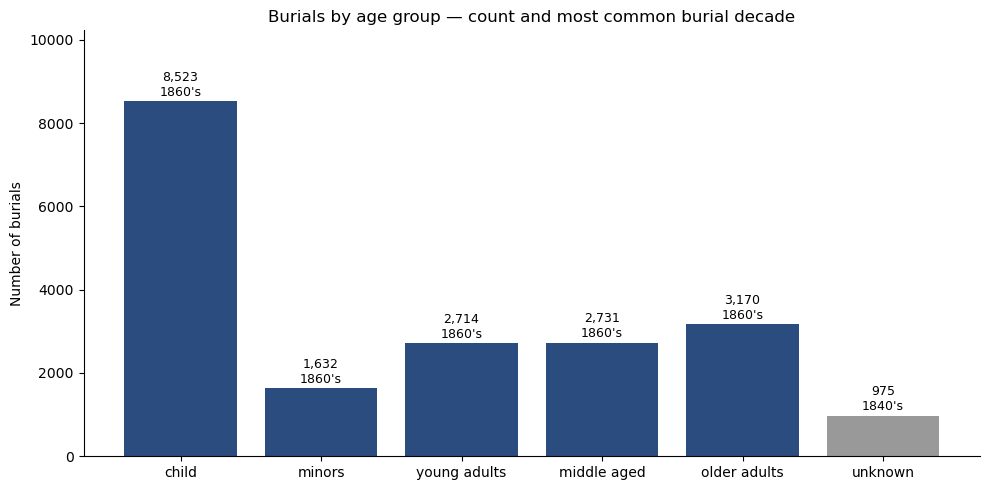

In [14]:
group_order = ["child", "minors", "young adults", "middle aged", "older adults", "unknown"]
counts = df["age group"].value_counts().reindex(group_order)
mode_decade = df.groupby("age group")["decade"].agg(lambda s: s.value_counts().idxmax()).reindex(group_order)

print(pd.DataFrame({"count": counts, "most common decade": mode_decade}))

colors = ["#2b4c7e"] * 5 + ["#999999"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(group_order, counts.values, color=colors)

for bar, count, decade in zip(bars, counts.values, mode_decade.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60, f"{count:,}\n{decade}",
            ha="center", va="bottom", fontsize=9)

ax.set_title("Burials by age group — count and most common burial decade")
ax.set_ylabel("Number of burials")
ax.set_ylim(0, counts.max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Child is the largest age group by a wide margin, with 8,523 burials, more than double the next-largest group, older adults, at 3,170. This comes from the corrected classification of infant burials described above; the majority of these records had previously fallen into the unknown category.

Every substantive age group, including child, shows the 1860's as its most common decade. That lines up with the Civil War-era mortality spike identified earlier and indicates that this measure mainly tracks which decade had the highest overall burial volume rather than anything age-specific.

The unknown category, now reduced to 975 records (4.9% of all burials), shows the 1840's as its most common decade, though the difference across decades is small. Of these 975 records, approximately 75 represent burials where identity itself was never recorded. The remaining approximately 900 are named individuals whose age simply was not documented, the practical floor for this classification given the source records.

## 8. Age Composition During the 1860's, Year by Year

The Civil War-era spike was examined at annual resolution rather than as a single averaged period, to determine whether the composition of who was dying changed as the spike unfolded. Both raw burial counts and each age group's share of total burials are presented for every year of the 1860's.

Burials by age group, each year of the 1860's:
age group    child  minors  young adults  middle aged  older adults  unknown
Burial Year                                                                 
1860.0         293      48            87           84            62        1
1861.0         221      54            59           61            56        4
1862.0         284      56            93           82            89       23
1863.0         413      78           103          109           116       17
1864.0         763     165           169          138           131        6
1865.0         692     144           198          166           139       27
1866.0         479     154           304          235           148       34
1867.0         262      52            88           83            52        5
1868.0         267      49            60           69            52        7
1869.0          61      15            52           32            23       26


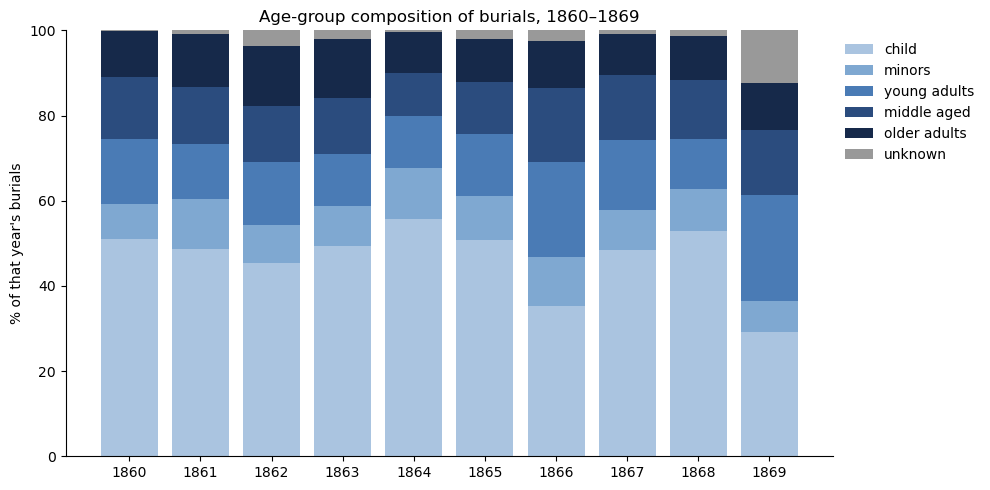

In [15]:
decade_1860s = df[(df["Burial Year"] >= 1860) & (df["Burial Year"] <= 1869)]
group_order = ["child", "minors", "young adults", "middle aged", "older adults", "unknown"]

counts_1860s = (decade_1860s.groupby(["Burial Year", "age group"]).size()
                .unstack(fill_value=0).reindex(columns=group_order))
print("Burials by age group, each year of the 1860's:")
print(counts_1860s)

pct_1860s = counts_1860s.div(counts_1860s.sum(axis=1), axis=0) * 100

colors = ["#aac4e0", "#7fa8d1", "#4a7bb5", "#2b4c7e", "#16294a", "#999999"]
year_labels = [str(int(y)) for y in pct_1860s.index]

fig, ax = plt.subplots(figsize=(10, 5))
bottom = pd.Series(0.0, index=pct_1860s.index)
for group, color in zip(group_order, colors):
    ax.bar(year_labels, pct_1860s[group], bottom=bottom.values, color=color, label=group)
    bottom += pct_1860s[group]

ax.set_title("Age-group composition of burials, 1860–1869")
ax.set_ylabel("% of that year's burials")
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False)
plt.tight_layout()
plt.show()

Examining the spike at annual resolution reveals a pattern the aggregated 1864–1866 comparison could not show: the composition of who died shifted noticeably as the spike progressed.

- **1864**: the most child-heavy year of the entire decade, with 763 child burials, 55.6% of that year's total. That is a higher child share than any surrounding non-spike year, which typically run 45% to 53%.
- **1866**: breaks sharply from that pattern. Child share falls to 35.4%, the lowest of the decade, while the young adult share rises to 22.5% (compared with a typical 12–16%) and middle-aged share rises to 17.4%. In raw terms, young adult burials nearly triple, from 103 in 1863 to 304 in 1866.
- **Interpretation**: the Civil War-era spike does not look like a single uniform event. It reads as two distinct waves: an early, child-heavy wave in 1864–65, in line with the ongoing burden of childhood disease at elevated volume, followed by a later wave in 1866 that skewed markedly toward working-age adults. The timing matches the documented 1866 cholera epidemic that reached the United States in the war's aftermath, spreading through wartime disruption to travel and the movement of soldiers and refugees. That is a plausible reason adults specifically would have faced greater exposure than in a typical year, though it remains an inference from timing rather than something the dataset can confirm directly.
- **1869**: appears to reflect a data-quality artifact rather than a genuine trend. Child share falls to 29.2% and the unknown share rises to 12.4%, compared with under 4% in every other year of the decade, but total burials that year number only 209, the smallest annual total in the 1860's. A year this sparsely recorded should not be read the same way as the well-populated spike years before it.